# Loan approval classifier: a beginner's walkthrough

This notebook walks through how we built a model that predicts whether a loan application is **approved (Y)** or **rejected (N)**.

**What is a classifier?** A classifier is a model that learns from past examples where we already know the answer (here, 614 past loan applications and their outcomes). It then uses the patterns it found to predict the answer for new examples.

**The plan:**
1. Load and explore the data
2. Clean it and create helpful new columns ("features")
3. Train several models and compare them fairly
4. Test the best one on data it has never seen
5. Understand what it learned and how to use it

Run the cells from top to bottom (Shift + Enter runs one cell).

## Step 0: Setup

We import the libraries we need. `pandas` handles tables, `matplotlib` draws charts, and `scikit-learn` (`sklearn`) provides the machine learning tools.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

# Our own project code (see loan_model.py and train.py in this folder)
from loan_model import add_features, make_pipeline
from train import CANDIDATES, RANDOM_STATE

# Colors used throughout: blue = approved, orange = rejected
APPROVED, REJECTED, GRID, INK = "#2a78d6", "#eb6834", "#e5e4e0", "#52514e"
plt.rcParams.update({
    "figure.figsize": (7, 3.6), "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GRID, "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.grid": True, "grid.color": GRID, "axes.axisbelow": True, "font.size": 10,
})
pd.set_option("display.width", 140)

## Step 1: Load and look at the data

Each **row** is one loan application. Each **column** is a piece of information about it. The last column, `Loan_Status`, is the answer we want to predict. In machine learning this is called the **target** (or label).

In [2]:
df = pd.read_csv("data/loan-approval.csv")
print(f"{df.shape[0]} rows (applications), {df.shape[1]} columns")
df.head()

614 rows (applications), 13 columns


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


What the columns mean:

| Column | Meaning |
|---|---|
| `Gender`, `Married`, `Dependents`, `Education`, `Self_Employed` | Facts about the applicant |
| `ApplicantIncome`, `CoapplicantIncome` | Monthly income of the applicant and any co-applicant |
| `LoanAmount` | Size of the loan (in thousands) |
| `Loan_Amount_Term` | Length of the loan in months (360 = 30 years) |
| `Credit_History` | 1 = meets credit guidelines, 0 = does not |
| `Property_Area` | Urban, Semiurban or Rural |
| `Loan_Status` | **The target:** Y = approved, N = rejected |

`Loan_ID` is just a name tag, so it carries no useful pattern. We'll leave it out.

### How many were approved?

This matters because it sets the **baseline**. If 69% were approved, a lazy "model" that says "approve" every time is already 69% accurate. Our model has to beat that to be useful.

Loan_Status
Y    422
N    192 

Approval rate: 68.7%


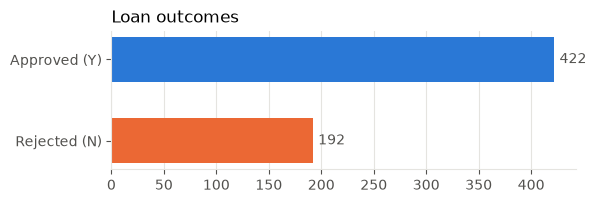

In [3]:
counts = df["Loan_Status"].value_counts()
print(counts.to_string(), "\n")
print(f"Approval rate: {counts['Y'] / len(df):.1%}")

fig, ax = plt.subplots(figsize=(6, 1.8))
ax.barh(["Rejected (N)", "Approved (Y)"], [counts["N"], counts["Y"]], color=[REJECTED, APPROVED], height=0.55)
for i, v in enumerate([counts["N"], counts["Y"]]):
    ax.text(v + 5, i, str(v), va="center", color=INK)
ax.set_title("Loan outcomes", loc="left")
ax.grid(axis="y", visible=False)
plt.show()

### Missing values

Real data is messy. Some applicants left fields blank (`NaN` = "not a number", i.e. missing). Most models can't handle blanks, so we need a plan for them.

In [4]:
missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False).to_frame("missing count")

,missing count
Credit_History,50
Self_Employed,32
LoanAmount,22
Dependents,15
Loan_Amount_Term,14
Gender,13
Married,3


`Credit_History` has the most blanks (50). Before we decide how to fill them, let's check how credit history relates to the outcome.

### The most important clue: credit history

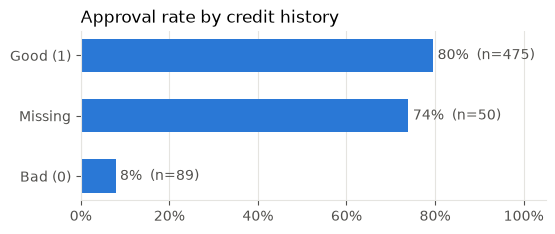

In [5]:
credit = df["Credit_History"].map({1.0: "Good (1)", 0.0: "Bad (0)"}).fillna("Missing")
rate = (df["Loan_Status"] == "Y").groupby(credit).mean().reindex(["Bad (0)", "Missing", "Good (1)"])
size = credit.value_counts().reindex(rate.index)

fig, ax = plt.subplots(figsize=(6, 2.2))
ax.barh(rate.index, rate.values, color=APPROVED, height=0.55)
for i, (r, n) in enumerate(zip(rate.values, size.values)):
    ax.text(r + 0.01, i, f"{r:.0%}  (n={n})", va="center", color=INK)
ax.set_xlim(0, 1.05)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.set_title("Approval rate by credit history", loc="left")
ax.grid(axis="y", visible=False)
plt.show()

This is a huge signal:
- With **bad** credit history, only **8%** were approved.
- With **good** credit history, **80%** were approved.
- Applicants with **missing** credit history were approved at **74%**, close to "good".

So rather than guessing a 0 or 1 for the blanks, we keep **"missing" as its own category** and let the model learn how to treat it.

### Does income matter?

Let's compare total household income for approved and rejected applications. Incomes are very spread out (a few people earn far more than everyone else), so we use a **log scale**, where equal distances on the axis mean equal multiples (1k to 10k is the same distance as 10k to 100k). Both outlines are scaled to the same total area, so we compare their *shapes* even though there are twice as many approvals.

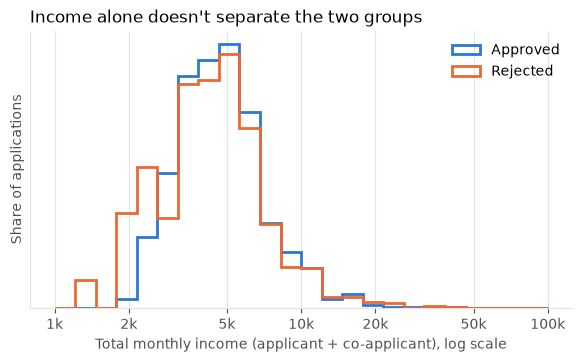

In [6]:
total_income = df["ApplicantIncome"] + df["CoapplicantIncome"]
bins = np.logspace(np.log10(1000), np.log10(100000), 25)

fig, ax = plt.subplots()
for status, color, label in [("Y", APPROVED, "Approved"), ("N", REJECTED, "Rejected")]:
    # density=True puts both groups on the same scale, even though there are more approvals
    ax.hist(total_income[df["Loan_Status"] == status], bins=bins, density=True,
            histtype="step", linewidth=2, color=color, label=label)
ax.set_xscale("log")
ticks = [1000, 2000, 5000, 10000, 20000, 50000, 100000]
ax.set_xticks(ticks, [f"{t // 1000}k" for t in ticks])
ax.minorticks_off()
ax.set_yticks([])
ax.set_xlabel("Total monthly income (applicant + co-applicant), log scale")
ax.set_ylabel("Share of applications")
ax.set_title("Income alone doesn't separate the two groups", loc="left")
ax.legend(frameon=False)
plt.show()

The two groups overlap almost completely, so income on its own isn't a strong clue. What may matter more is whether the loan is **affordable relative to income**. That's the idea behind the new features in the next step.

## Step 2: Feature engineering (creating helpful columns)

**Feature engineering** means creating new columns that make patterns easier for the model to find. Our function `add_features` (in `loan_model.py`) adds:

| New feature | How it's calculated | Why it helps |
|---|---|---|
| `LogTotalIncome` | log of (applicant + co-applicant income) | Shrinks huge incomes so a few very rich applicants don't dominate |
| `LogLoanAmount` | log of the loan amount | Same idea for loan size |
| `LoanToIncome` | loan amount ÷ total income | How big is the loan compared to what they earn? |
| `EMIToIncome` | (loan ÷ term) ÷ total income | Roughly, the monthly repayment as a share of income (EMI = "equated monthly installment") |

It also turns `Credit_History` into the three categories "1", "0" and "missing", as decided above.

In [7]:
X_raw = df.drop(columns=["Loan_ID", "Loan_Status"])
add_features(X_raw)[["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term",
                     "Credit_History", "LogTotalIncome", "LoanToIncome", "EMIToIncome"]].head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,LogTotalIncome,LoanToIncome,EMIToIncome
0,5849,0.0,NaN,360.0,1,8.674197,NaN,NaN
1,4583,1508.0,128.0,360.0,1,8.714732,0.021015,0.000058
2,3000,0.0,66.0,360.0,1,8.006701,0.022000,0.000061
3,2583,2358.0,120.0,360.0,1,8.505525,0.024287,0.000067
4,6000,0.0,141.0,360.0,1,8.699681,0.023500,0.000065


## Step 3: Split the data into training and test sets

This is one of the most important ideas in machine learning.

If we tested the model on the same applications it learned from, it could simply memorise the answers and look brilliant without being useful. So we **hide 20% of the data** as a **test set** and only look at it once, at the very end. It plays the role of "future applications" the model has never seen.

`stratify=y` keeps the 69/31 approved/rejected mix the same in both parts. `random_state` makes the random split repeatable, so you get the same numbers every time.

In [8]:
X = df.drop(columns=["Loan_ID", "Loan_Status"])
y = (df["Loan_Status"] == "Y").astype(int)   # convert Y/N to 1/0, which models need

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Training set: {len(X_train)} rows   Test set: {len(X_test)} rows")
print(f"Approval rate: train {y_train.mean():.1%}, test {y_test.mean():.1%}")

Training set: 491 rows   Test set: 123 rows
Approval rate: train 68.6%, test 69.1%


## Step 4: Build a pipeline

A **pipeline** chains every preparation step and the model together, so new data always goes through exactly the same steps. Ours does:

1. **Add features**: the new columns from Step 2.
2. **Fill in missing values** ("imputation"):
   - text columns get the most common value,
   - number columns get the **median** (the middle value, which isn't thrown off by extreme incomes).
3. **One-hot encode** text columns. Models only understand numbers, so `Property_Area = Urban` becomes three 0/1 columns: `Urban=1, Semiurban=0, Rural=0`.
4. **Scale** number columns to a similar range, so a column measured in thousands doesn't outweigh one measured in single digits.
5. **The model** itself.

A bonus of the pipeline: the medians and most common values are learned **only from training data**, so no information from the test set sneaks in. Sneaking test information into training is called **data leakage**, and it makes results look better than they really are.

In [9]:
make_pipeline(CANDIDATES["random forest"])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('features', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...x7f2af1a7c9a0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDicti

## Step 5: Compare several models fairly

We try four models:

| Model | In plain words |
|---|---|
| **Baseline** | Always says "approve". Any real model must beat this. |
| **Logistic regression** | Gives each feature a weight, adds them up, and turns the total into a probability. Simple and easy to explain. |
| **Random forest** | Builds hundreds of decision trees (flowcharts of yes/no questions) on random slices of the data, then lets them vote. |
| **Gradient boosting** | Builds small trees one after another, each one trying to fix the previous trees' mistakes. |

### Cross-validation

To compare them without touching the test set, we use **5-fold cross-validation**. The training set is cut into 5 pieces. Each model trains on 4 pieces and is scored on the 5th, and this repeats 5 times so every piece gets a turn as the scoring piece. Averaging the 5 scores gives a more reliable estimate than a single split.

### The scores we track
- **Accuracy**: share of predictions that are correct.
- **ROC AUC**: how well the model **ranks** applications, from 0.5 (coin flip) to 1.0 (perfect). If you pick one random approved and one random rejected application, it's the chance the model gives the approved one a higher score. It isn't fooled by imbalanced classes the way accuracy is.
- **F1 (reject)**: how well the model finds **rejections**, balancing "how many it caught" and "how often it was right". The baseline scores 0 here because it never predicts a rejection.

This cell takes a few seconds to run.

In [10]:
from sklearn.metrics import make_scorer, f1_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "roc_auc": "roc_auc", "f1_reject": make_scorer(f1_score, pos_label=0)}

rows = []
for name, model in CANDIDATES.items():
    s = cross_validate(make_pipeline(model), X_train, y_train, cv=cv, scoring=scoring)
    rows.append({"model": name,
                 "accuracy": s["test_accuracy"].mean(),
                 "roc_auc": s["test_roc_auc"].mean(), "roc_auc_std": s["test_roc_auc"].std(),
                 "f1_reject": s["test_f1_reject"].mean()})
cv_results = pd.DataFrame(rows).set_index("model")
cv_results.round(3)

,accuracy,roc_auc,roc_auc_std,f1_reject
model,,,,
baseline (always approve),0.686,0.500,0.000,0.000
logistic regression,0.790,0.725,0.085,0.542
random forest,0.794,0.770,0.087,0.540
gradient boosting,0.788,0.761,0.059,0.552


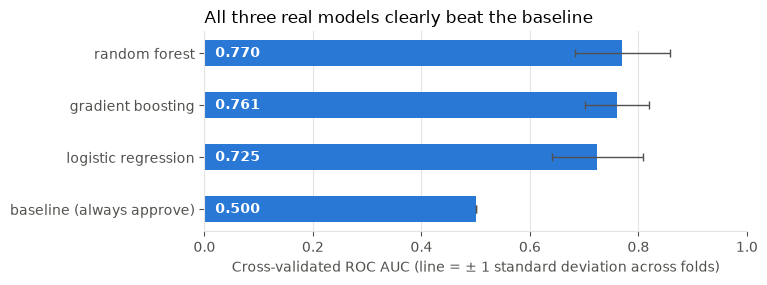

In [11]:
fig, ax = plt.subplots(figsize=(7, 2.6))
order = cv_results.sort_values("roc_auc")
ax.barh(order.index, order["roc_auc"], xerr=order["roc_auc_std"], color=APPROVED, height=0.5,
        error_kw={"ecolor": INK, "capsize": 3, "linewidth": 1})
for i, v in enumerate(order["roc_auc"]):
    ax.text(0.02, i, f"{v:.3f}", va="center", color="white", fontweight="bold")
ax.set_xlim(0, 1)
ax.set_xlabel("Cross-validated ROC AUC (line = ± 1 standard deviation across folds)")
ax.set_title("All three real models clearly beat the baseline", loc="left")
ax.grid(axis="y", visible=False)
plt.show()

**How to read this:** all three real models beat the baseline by a wide margin. The **random forest** has the highest average ROC AUC, so we pick it.

The black lines show how much each score varied across the 5 folds, and they overlap a lot. With only ~500 training rows, the three models are honestly very close. Picking the top one is reasonable, but don't read too much into small gaps.

## Step 6: The final exam on the test set

Now we train the random forest on the full training set and score it **once** on the 123 test applications it has never seen.

In [12]:
model = make_pipeline(CANDIDATES["random forest"]).fit(X_train, y_train)

test_proba = model.predict_proba(X_test)[:, 1]   # probability of approval, from 0 to 1
test_pred = model.predict(X_test)                # 1 if probability >= 0.5, else 0

print(f"Test accuracy: {accuracy_score(y_test, test_pred):.1%}   (baseline: {y_test.mean():.1%})")
print(f"Test ROC AUC:  {roc_auc_score(y_test, test_proba):.3f}")

Test accuracy: 85.4%   (baseline: 69.1%)
Test ROC AUC:  0.868


### The confusion matrix: where is it right and wrong?

A **confusion matrix** counts each combination of *actual* answer and *predicted* answer. The diagonal (top-left and bottom-right) holds the correct predictions.

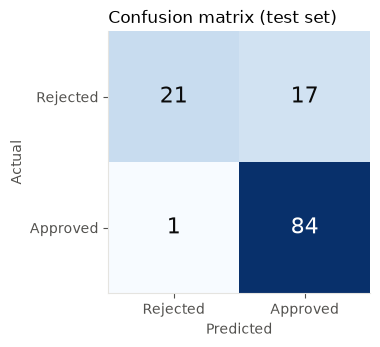

              precision    recall  f1-score   support

    Rejected      0.955     0.553     0.700        38
    Approved      0.832     0.988     0.903        85

    accuracy                          0.854       123
   macro avg      0.893     0.770     0.802       123
weighted avg      0.870     0.854     0.840       123



In [13]:
cm = confusion_matrix(y_test, test_pred)
labels = ["Rejected", "Approved"]

fig, ax = plt.subplots(figsize=(4.2, 3.4))
ax.imshow(cm, cmap="Blues")
ax.grid(False)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=16,
                color="white" if cm[i, j] > cm.max() / 2 else "#0b0b0b")
ax.set_xticks([0, 1], labels)
ax.set_yticks([0, 1], labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion matrix (test set)", loc="left")
plt.show()

print(classification_report(y_test, test_pred, target_names=["Rejected", "Approved"], digits=3))

**Reading the results:**
- Of 85 actually **approved** applications, the model got 84 right (99% **recall**: it "recalls" almost all of them).
- Of 38 actually **rejected** applications, it caught only 21 (55% recall). It missed 17, mostly applicants with good credit history who were rejected for other reasons.
- When it *does* predict a rejection, it's right 95% of the time (that's **precision**).

So the model is cautious about predicting rejections: when it says "reject" it's almost always right, but it lets many rejections through as "approve".

The test score (85%) is higher than the cross-validation score (79%). With only 123 test rows, some luck is involved, so expect something closer to 80% on new data.

## Step 7: What did the model learn?

A random forest can tell us how much each feature helped its decisions (its **feature importance**). Higher means the trees relied on it more often to split good applications from bad ones.

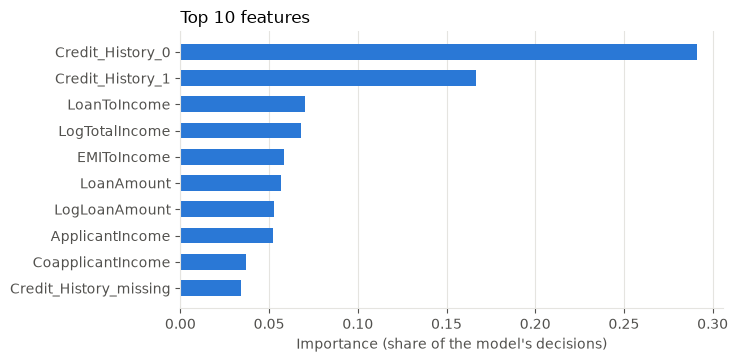

In [14]:
names = model.named_steps["preprocess"].get_feature_names_out()
names = [n.split("__", 1)[1] for n in names]   # drop the "cat__" / "num__" prefixes
importance = pd.Series(model.named_steps["model"].feature_importances_, index=names).sort_values()
top = importance.tail(10)

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(top.index, top.values, color=APPROVED, height=0.6)
ax.set_xlabel("Importance (share of the model's decisions)")
ax.set_title("Top 10 features", loc="left")
ax.grid(axis="y", visible=False)
plt.show()

As the exploration suggested, **credit history dominates**. After that come the affordability features we engineered (`LoanToIncome`, `LogTotalIncome`, `EMIToIncome`), which beat the raw income and loan amount columns. That's feature engineering paying off.

## Step 8: Tuning the decision threshold

By default, the model says "approve" when its approval probability is at least **0.5**. That cut-off is just a choice. If missing a bad loan is costly, we can demand more confidence before approving, for example 0.7.

Let's see the trade-off on the test set:

In [15]:
rows = []
for t in [0.5, 0.6, 0.7, 0.75, 0.8]:
    pred = (test_proba >= t).astype(int)
    caught = ((pred == 0) & (y_test == 0)).sum()
    wrongly_rejected = ((pred == 0) & (y_test == 1)).sum()
    rows.append({"threshold": t, "accuracy": accuracy_score(y_test, pred),
                 "rejections caught (of 38)": caught, "good applicants wrongly rejected (of 85)": wrongly_rejected})
pd.DataFrame(rows).set_index("threshold").round(3)

,accuracy,rejections caught (of 38),good applicants wrongly rejected (of 85)
threshold,,,
0.50,0.854,21,1
0.60,0.894,28,3
0.70,0.813,31,16
0.75,0.659,33,37
0.80,0.545,35,53


Raising the threshold catches more bad loans but turns away more good applicants. No threshold is "correct". It's a business decision about which mistake costs more.

Notice that 0.6 even improves accuracy here (85% → 89%). Tempting, but careful: we just used the **test set** to choose it, and the test set is meant to be looked at only once. Choosing settings by peeking at it makes the score look better than it will be on truly new data. The honest way is to choose the threshold with cross-validation on the training set, then confirm it once on the test set.

## Step 9: Using the model on a new application

Finally, we train on **all** 614 rows (more data generally means a better model) and score a made-up applicant. The `train.py` script does exactly this and saves the result, and `predict.py` scores a whole CSV of new applications.

In [16]:
final_model = make_pipeline(CANDIDATES["random forest"]).fit(X, y)

new_applicants = pd.DataFrame([
    {"Gender": "Female", "Married": "Yes", "Dependents": "1", "Education": "Graduate",
     "Self_Employed": "No", "ApplicantIncome": 4500, "CoapplicantIncome": 1500,
     "LoanAmount": 130, "Loan_Amount_Term": 360, "Credit_History": 1.0, "Property_Area": "Semiurban"},
    {"Gender": "Female", "Married": "Yes", "Dependents": "1", "Education": "Graduate",
     "Self_Employed": "No", "ApplicantIncome": 4500, "CoapplicantIncome": 1500,
     "LoanAmount": 130, "Loan_Amount_Term": 360, "Credit_History": 0.0, "Property_Area": "Semiurban"},
], index=["Good credit history", "Bad credit history"])

proba = final_model.predict_proba(new_applicants)[:, 1]
for who, p in zip(new_applicants.index, proba):
    print(f"{who}: approval probability {p:.0%} -> {'APPROVE' if p >= 0.5 else 'REJECT'}")

Good credit history: approval probability 85% -> APPROVE
Bad credit history: approval probability 22% -> REJECT


The two applicants are identical except for credit history, and that alone flips the decision.

## Summary

| Step | What we did |
|---|---|
| Explore | 614 applications, 69% approved; credit history is the strongest clue |
| Clean | Filled blanks with the median or most common value; kept missing credit history as its own category |
| Features | Added affordability ratios (loan-to-income, repayment-to-income) and log-scaled amounts |
| Compare | Cross-validated 4 models; random forest was best (ROC AUC ≈ 0.77) |
| Test | 85% accuracy on unseen data vs 69% for always-approve; catches about half of rejections |

### Limitations and next steps
- **Small dataset.** Scores vary a lot between splits. More data would help more than a fancier model.
- **Misses many rejections.** Tune the threshold (Step 8) to match how costly each kind of mistake is.
- **Fairness.** `Gender` and `Married` are inputs. For real lending decisions these may be legally protected, so try removing them and see how much accuracy changes (likely very little).
- **Ideas to try:** hyperparameter tuning with `GridSearchCV`, or `class_weight="balanced"` to make the model pay more attention to rejections.